# **Machine Learning Final Exam**
#### Cayleigh Goberman
#### 12/8/25

**Question 1) Backpropagation**

We are going to consider a simple linear regression with one observation
(pair of values x,y), as in the example presented in the lecture notes, but with a twist: we are
dealing with a regularized simple linear regression, with L2 regularization. This means that
the regularized cost function (that coincides with the regularized loss function, as we are
dealing with one observation) is:


Jreg = J + (lambda) * R

with J = (1/2)(yhat - y)^2

R = (1/2)w^2 (L2 Regulatization)
lambda (Hyperparameter, just a constant)


The linear regression is, of course:

yhat = w * x + b

You must build the computational graph and formulate the forward pass (this is a giveaway)
and the backward pass. No need for vectorization, as there is is just one observation.

In [ ]:
from os import waitpid
from IPython.core.display import display_pretty
def forward(yhat, y, w, l):
  J = (1/2) * ((yhat - y) ** 2)
  R = (1/2) * (w ** 2)
  Jreg = J + l * R
  return Jreg, J, l, R

def backward(yhat, y, w, l, J, R, Jreg):
  dJ = l * R
  dl = J * R
  dR = J * l

  dyhat = dJ * (yhat - y) # dJ/dyhat = yhat - y
  dy = dJ * (yhat - y) # dJ/dy = yhat - y
  dw = dR * w # dR/dw = w

  return {
        "yhat": yhat, "y": y, "w": w,
        "J": J, "l": l, "R": R,
        "Jreg": Jreg,
        "dJ": dJ, "dl": dl, "dR": dR,
        "dyhat": dyhat, "dy": dy, "dw": dw
    }

Jreg, J, l, R = forward(2.0, 1.0, 1.0, 2.0);
res = backward(2.0, 1.0, 1.0, l, J, R, Jreg);

print("=== Forward pass ===")
print(f"Jreg={res['Jreg']}, J={res['J']}, l={res['l']}, R={res['R']}")

print("\n=== Backward pass ===")
print(f"dJ = {res['dJ']:.1f}, dl = {res['dl']:.1f}, dR = {res['dR']:.1f}")
print(f"dyhat = {res['dyhat']:.1f}, dy = {res['dy']:.1f}, dw = {res['dw']:.1f}")

=== Forward pass ===
Jreg=1.5, J=0.5, l=2.0, R=0.5

=== Backward pass ===
dJ = 1.0, dl = 0.2, dR = 1.0
dyhat = 1.0, dy = 1.0, dw = 1.0


**Question 2) Sentiment Analysis**

Given the following miniature training and test sets of documents belonging to classes: positive(+) and negative (-), use the data to train a multinomial NB model. What are the Prior probabilities P(+) and P(-), and the -log conditional probabilities for each word P(wi|+) and P(wi|-)?

Then use the model to predict the sentiment of the next review. You can solve it manually, or using sklean.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We were not provided with a link to documentation of this dataset, so we will have to make it from scratch
reviews = [
    "just plain boring",
    "predictable",
    "no surprises and few laughs",
    "very powerful",
    "the most fun film"
]
sentiments = ["-", "-", "-", "+", "+"]

new_review = ["predictable and no fun"]

# Convert to a DataFrame
df = pd.DataFrame({'Text': reviews, 'Sentiments': sentiments})
print(df)

                          Text Sentiments
0            just plain boring          -
1                  predictable          -
2  no surprises and few laughs          -
3                very powerful          +
4            the most fun film          +


In [ ]:
from sklearn.model_selection import train_test_split
# Split the data into train and test sets
X = df['Text']
y = df['Sentiments']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#We use this to convert the target labels '+' and '-' into 1 and 0 respectively.
y_train = np.where(y_train=='+',1,0)
y_test = np.where(y_test=='+',1,0)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Need CountVectorizer to turn the text reviws into a vector of counts that multinomial NB can work with
count_vect = CountVectorizer()

# Transform X_train and X_test into term-document matrices (Bag of Words)
tf_train= count_vect.fit_transform(X_train)
tf_test = count_vect.transform(X_test)

# Get vocabulary
vocab = count_vect.get_feature_names_out()

# Let's see our bag of words
print(vocab)

['and' 'boring' 'few' 'just' 'laughs' 'no' 'plain' 'powerful' 'surprises'
 'very']


In [ ]:
# Let's one-hot encode the data so we can detect the prior and -log conditional probabilities
from sklearn.naive_bayes import BernoulliNB

df1=pd.get_dummies(df, dtype = float)
print(df1)

X=df1.values[:,0:6]
y=df1.values[:,6]
print (X,'\n',y)

# Get the model
Bnb_model = BernoulliNB(alpha=1)
Bnb_model.fit(X, y)

class_logpriors= Bnb_model.class_log_prior_
# Prior probabilities
print("Prior Probabilities: ", np.exp(class_logpriors))

# log(P(xi|cj))
logprobs = Bnb_model.feature_log_prob_

# Arrange them nicely
pd.DataFrame(data = logprobs, columns = dfw1.columns[0:6])

   Text_just plain boring  Text_no surprises and few laughs  Text_predictable  \
0                     1.0                               0.0               0.0   
1                     0.0                               0.0               1.0   
2                     0.0                               1.0               0.0   
3                     0.0                               0.0               0.0   
4                     0.0                               0.0               0.0   

   Text_the most fun film  Text_very powerful  Sentiments_+  Sentiments_-  
0                     0.0                 0.0           0.0           1.0  
1                     0.0                 0.0           0.0           1.0  
2                     0.0                 0.0           0.0           1.0  
3                     0.0                 1.0           1.0           0.0  
4                     1.0                 0.0           1.0           0.0  
[[1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0

,Text_just plain boring,Text_no surprises and few laughs,Text_predictable,Text_the most fun film,Text_very powerful,Sentiments_+
0,-1.386294,-1.386294,-1.386294,-0.693147,-0.693147,-0.287682
1,-0.916291,-0.916291,-0.916291,-1.609438,-1.609438,-1.609438


In [ ]:
# Training and testing a multinomial NB model
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB().fit(tf_train, y_train)

# Get probabilities (prior probabilities), then print it
probs = model.predict_proba(tf_test)[:,1]
print(probs)

# Get predictions
predictions = model.predict(tf_test)
print(predictions)

#These are the log(P(xi|cj))
#logprobs = Bnb_model.feature_log_prob_
#logprobs

# Just to be clear on the new review (we need to vectorize it too)
predicted_review = model.predict(count_vect.transform(new_review))
print(f"The predicted review is: {predicted_review[0]}")

[0.33333333 0.33333333]
[0 0]
The predicted review is: 0




Accuracy.........: 50.0000
Precision........: 0.0000
Recall...........: 0.0000
FP Rate...........:0.0000
ROC AUC (probs)..: 0.500000
F1 score.........:0.0000

Confusion matrix.:
 [[1 0]
 [1 0]]



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'\nThese are not very good results. All of our evaluated values are terrible.\nAccuracy is low, most of the others are at zero, and the ROC AUC is at 50%, which indicates a result that is basically the same as guessing randomly.\nThis could be due to the extremely small sample size; there was not much to train the data on.\n'

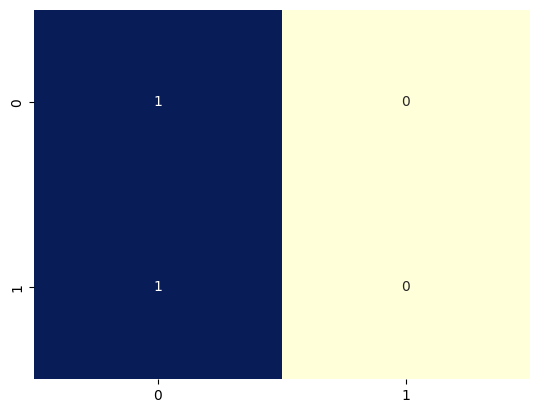

In [ ]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score,auc, f1_score
from sklearn.metrics import confusion_matrix,roc_curve, precision_recall_curve

accuracy = accuracy_score(y_test, predictions)
precision=precision_score(y_test, predictions)
recall=recall_score(y_test, predictions)
specificity=recall_score(y_test, predictions, pos_label=0)
roc = roc_auc_score(y_test, probs)
f1=f1_score(y_test, predictions)

print("\n")
print(f"Accuracy.........: {accuracy * 100.0:.4f}")
print(f"Precision........: {precision *100:.4f}")
print(f"Recall...........: {recall * 100:.4f}")
print(f"FP Rate...........:{(1-specificity) * 100:.4f}")
print(f"ROC AUC (probs)..: {roc:.6f}")
print(f"F1 score.........:{(f1):.4f}")

cm = confusion_matrix(y_test, predictions)
print(f"\nConfusion matrix.:\n {cm}\n")
sns.heatmap(cm, annot=True,fmt='d',cbar=False,cmap="YlGnBu");

'''
These are not very good results. All of our evaluated values are terrible.
Accuracy is low, most of the others are at zero, and the ROC AUC is at 50%, which indicates a result that is basically the same as guessing randomly.
This could be due to the extremely small sample size; there was not much to train the data on.
'''